## Gradient descent in 2D

Desenvolver o gradiente em duas dimensões de maneira similar com ao caso 1D.

In [1]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym # permite calcular as derivadas parciais

### Gradiente descent in 2D

In [33]:
# the peaks function

def peaks(x,y):
    # garantindo a conversão dos dados para evitar conflito entre numpy e sympy
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    # expand to a 2D mesh
    x,y = np.meshgrid(x,y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) \
          - 10*(x/5 - x**3 - y**5) * np.exp(-x**2-y**2) \
          - 1/3*np.exp(-(x+1)**2 - y**2)
    return z

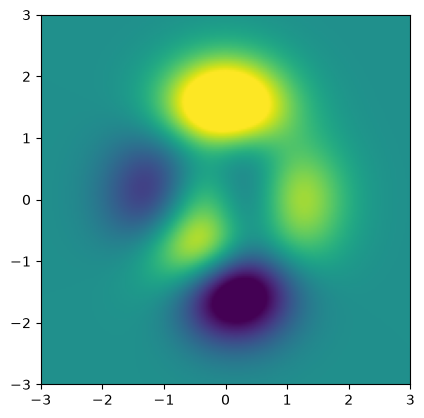

In [34]:
# create the landscape

x = np.linspace(-3,3,201)
y = np.linspace(-3,3,201)

Z = peaks(x,y)

# Let's have a look
plt.imshow(Z,extent=[x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5,origin='lower')
plt.show()

In [35]:
# create derivative functions using sympy

sx,sy = sym.symbols('sx,sy')

sZ = 3*(1-sx)**2 * sym.exp(-(sx**2) - (sy+1)**2) \
      - 10*(sx/5 - sx**3 - sy**5) * sym.exp(-sx**2-sy**2) \
      - 1/3*sym.exp(-(sx+1)**2 - sy**2)

# create functions from the sympy-computed derivatives

df_x = sym.lambdify( (sx,sy), sym.diff(sZ,sx),'sympy')
df_y = sym.lambdify( (sx,sy), sym.diff(sZ,sy),'sympy')

df_x(1,1).evalf()

-1.07369833656079

In [86]:
# random starting point (uniform between -2 and +2)

localmin = np.random.rand(2)*4 - 2
startpnt = localmin[:] # make a copy

# learning parameters
learning_rate = 0.01
training_epochs = 1000

# run through training
trajectory = np.zeros((training_epochs,2)) # defino minha matriz nula que vou popular com dados de x,y

for i in range(training_epochs):
    grad = np.array([df_x(localmin[0],localmin[1]).evalf(),
                     df_y(localmin[0],localmin[1]).evalf()
                     ])
    localmin = localmin - learning_rate*grad
    trajectory[i,:] = localmin
    
    # if (peaks(*localmin) - peaks(*startpnt)) < 0:
    #     localmin = localmin - learning_rate*grad
    #     trajectory[i,:] = localmin
    # else:
    #     localmin = localmin + learning_rate*grad
    #     trajectory[i,:] = localmin

print(localmin)
print(startpnt)

[0.228278920556369 -1.62553495750000]
[ 1.64478196 -1.430003  ]


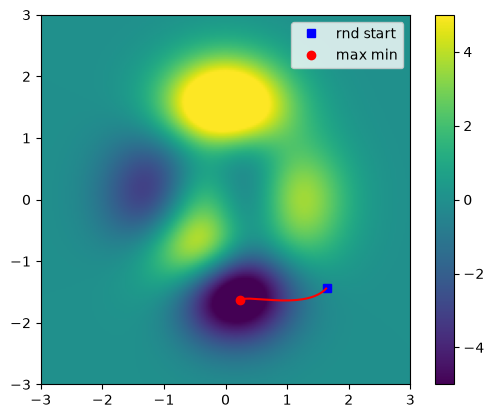

In [87]:
# let's have a look!
plt.imshow(Z,extent=[x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5,origin='lower')
plt.plot(startpnt[0],startpnt[1],'bs')
plt.plot(localmin[0],localmin[1],'ro')
plt.plot(trajectory[:,0],trajectory[:,1],'r')
plt.legend(['rnd start','max min'])
plt.colorbar()
plt.show()

### Algumas ideias sobre o código

1) Modifique o código para forçar a estimativa inicial a ser [0, 1.4]. O modelo chega a um mínimo local razoável?

2) Usando o mesmo ponto de partida, altere o número de épocas de treinamento para 10.000. A solução final difere daquela
obtida com 1.000 épocas?

3) (Novamente com o mesmo ponto de partida) Altere a taxa de aprendizado para 0.1 (1.000 épocas). O que você observa em relação à trajetória? 
Tente novamente com a taxa de aprendizado definida como 0,5 e, depois, como 0,00001.

---
Quando eu inicio em um máximo [0,1.4] eu chego em um mesmo ponto que não é mínimo local. Mesmo alterando o número de épocas o resultado é o mesmo, aparentemente o aprendizado ficou preso em um mínimo local e não consegue sair. Para isso é preciso alterar a taxa de aprendizado. Usando 0.1 tivemos o mesmo resultados para 1000 épocas, porém com uma trajetória mais abrupta. Em 0.5 de aprendizado ele apresenta comportamento maluco. Alterando para menores aprendizados o resultado são curvas suaves, porém não chegamos a mínimo nenhum.


## CodeChallenge: 2D gradient ascent

queremos obter o máximo local e não mínimo. Para isso, devemos considerar os pontos em que a deriva é nula, mas além disso verificar se os pontos na função, a cada iteração, está aumentando ou diminuindo.

Eu comparo o passo dado $i+1$ com o anterior $i$, se $f(x_{i+1},y_{i+1}) - f(x_i,y_i) < 0$ eu faço com que o máximo local subtraia valores, pois o passo dado causou uma valor da função menor que o anterior. Caso a diferença seja maior ou igual, então eu adicionar valores à variável máximo local.

In [ ]:
# random starting point (uniform between -2 and +2)

localmax = np.random.rand(2)*4 - 2
startpnt = localmax[:] # make a copy

# learning parameters
learning_rate = 0.01
training_epochs = 1000

# run through training
trajectory = np.zeros((training_epochs,2)) # defino minha matriz nula que vou popular com dados de x,y

for i in range(training_epochs):
    grad = np.array([df_x(localmax[0],localmax[1]).evalf(),
                     df_y(localmax[0],localmax[1]).evalf()
                     ])
    # adiciono essa análise para saber o sentido da f(x,y)
    if (peaks(*localmax) - peaks(*startpnt)) < 0:
        localmax = localmax - learning_rate*grad
        trajectory[i,:] = localmax
    else:
        localmax = localmax + learning_rate*grad
        trajectory[i,:] = localmax

print(localmax)
print(startpnt)

[1.28568469724130 -0.00484755907559365]
[1.07611424 0.29630075]


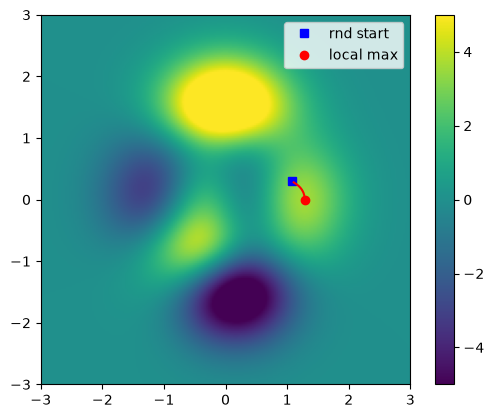

In [96]:
# let's have a look!
plt.imshow(Z,extent=[x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5,origin='lower')
plt.plot(startpnt[0],startpnt[1],'bs')
plt.plot(localmax[0],localmax[1],'ro')
plt.plot(trajectory[:,0],trajectory[:,1],'r')
plt.legend(['rnd start','local max'])
plt.colorbar()
plt.show()